# Distribution

### Data load

In [58]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Histogram

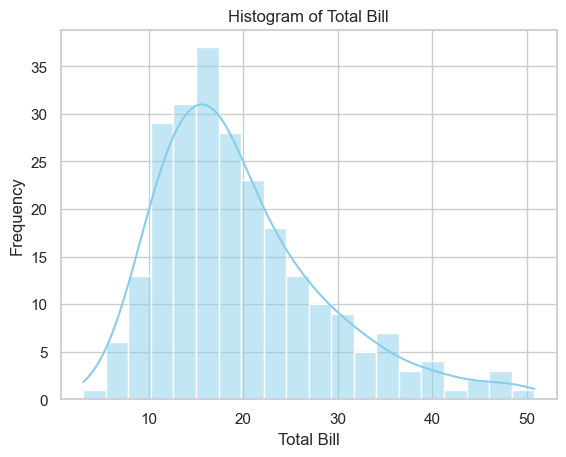

In [59]:
sns.histplot(tips["total_bill"], kde=True, bins=20, color='skyblue')
plt.title("Histogram of Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.show()

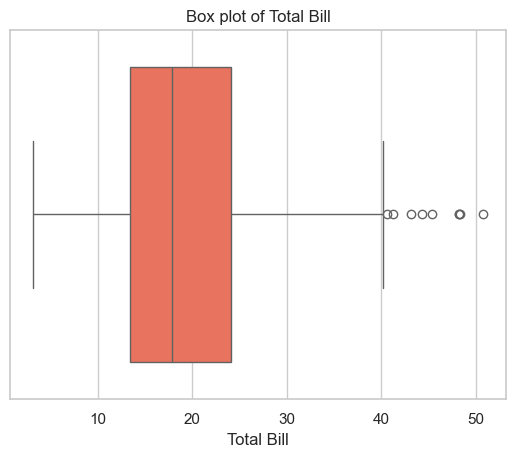

In [60]:
sns.boxplot(x=tips["total_bill"], color='tomato')
plt.title("Box plot of Total Bill")
plt.xlabel("Total Bill")
plt.show()

C:\Users\ramir\AppData\Local\Temp\ipykernel_94872\1704318626.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=tips["day"], y=tips["total_bill"], palette="Pastel1")


<Axes: xlabel='day', ylabel='total_bill'>

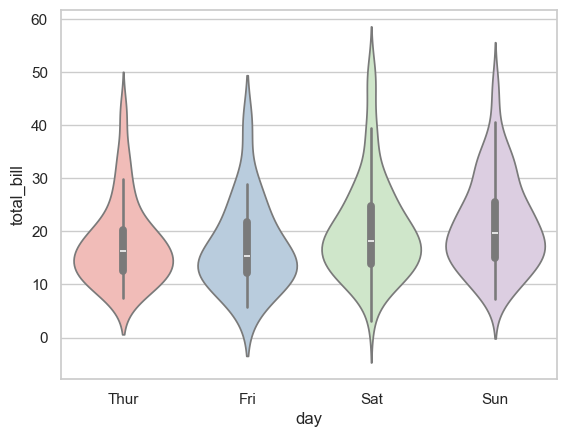

In [61]:
sns.violinplot(x=tips["day"], y=tips["total_bill"], palette="Pastel1")

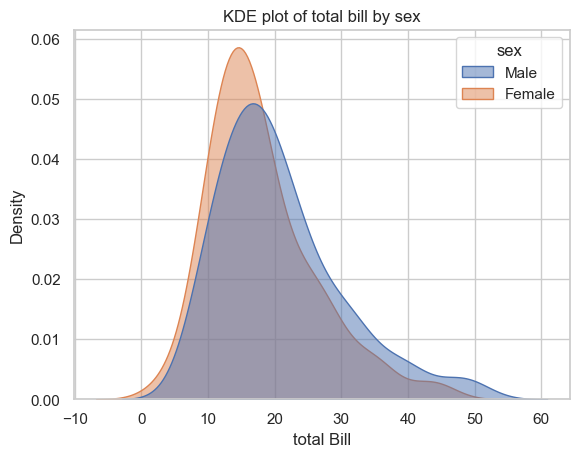

In [62]:
sns.kdeplot(data=tips, x='total_bill', hue='sex', fill=True, common_norm=False, alpha=0.5)
plt.title("KDE plot of total bill by sex")
plt.xlabel("total Bill")
plt.show()

In [63]:
help(np.random.normal)

Help on built-in function normal:

normal(...) method of numpy.random.mtrand.RandomState instance
    normal(loc=0.0, scale=1.0, size=None)

    Draw random samples from a normal (Gaussian) distribution.

    The probability density function of the normal distribution, first
    derived by De Moivre and 200 years later by both Gauss and Laplace
    independently [2]_, is often called the bell curve because of
    its characteristic shape (see the example below).

    The normal distributions occurs often in nature.  For example, it
    describes the commonly occurring distribution of samples influenced
    by a large number of tiny, random disturbances, each with its own
    unique distribution [2]_.

    .. note::
        New code should use the `~numpy.random.Generator.normal`
        method of a `~numpy.random.Generator` instance instead;
        please see the :ref:`random-quick-start`.

    Parameters
    ----------
    loc : float or array_like of floats
        Mean ("centre") o

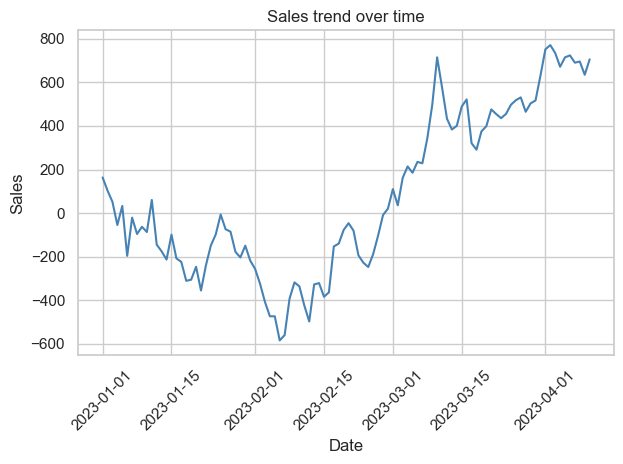

In [64]:
np.random.seed(1)
dates = pd.date_range("2023-01-01", periods=100)
sales = np.random.normal(loc=1, scale=100, size=100).cumsum()
df = pd.DataFrame({"Date":dates, "Sales":sales})

plt.plot(df["Date"], df["Sales"], color="steelblue")
plt.title("Sales trend over time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

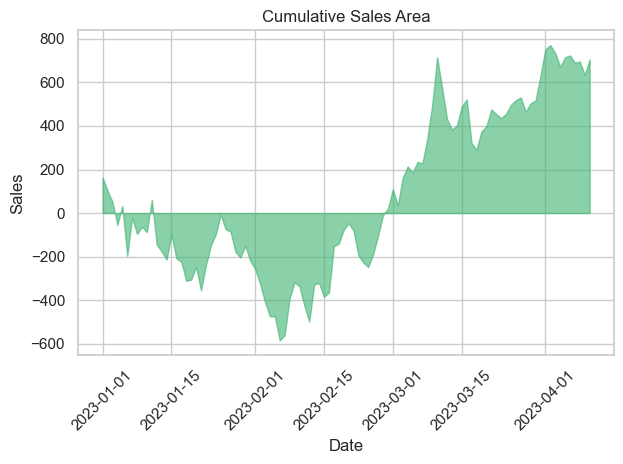

In [65]:
plt.fill_between(df["Date"], df["Sales"], color="mediumseagreen", alpha=0.6)
plt.title("Cumulative Sales Area")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\ramir\AppData\Local\Temp\ipykernel_94872\1301654551.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range("2023-01-01", periods=24*7, freq="H")  # 1 week of hourly data


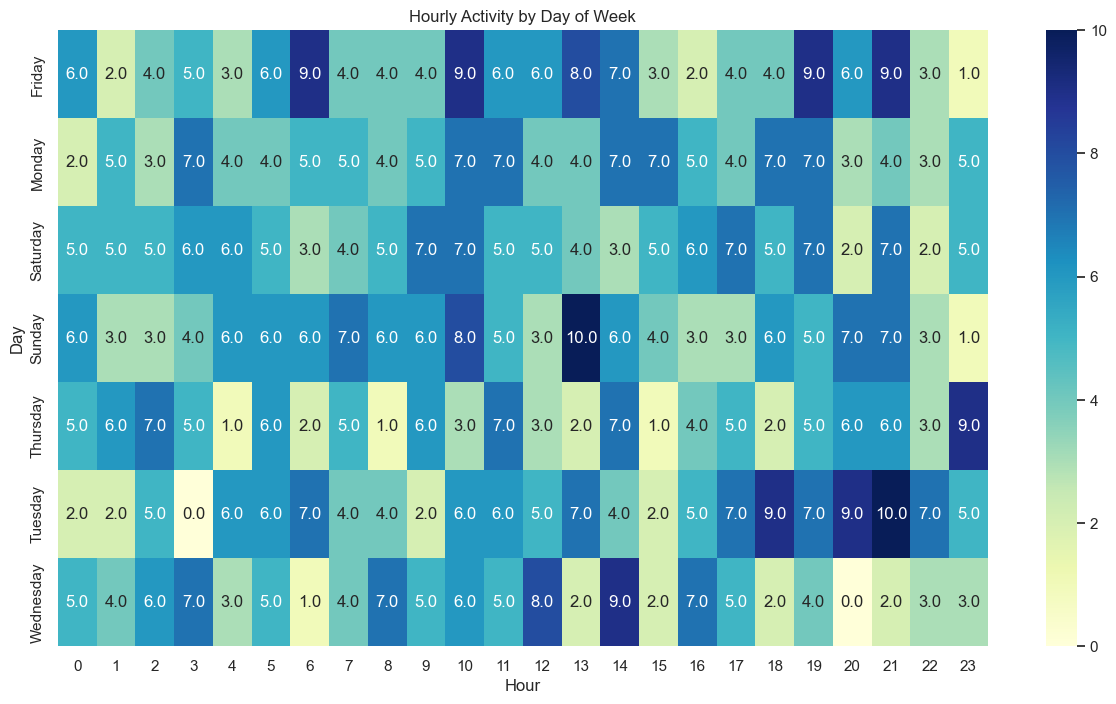

In [66]:
import seaborn as sns

# Simulate hourly data for heatmap
np.random.seed(7)
dates = pd.date_range("2023-01-01", periods=24*7, freq="H")  # 1 week of hourly data
df_heat = pd.DataFrame({
    "datetime": dates,
    "value": np.random.poisson(5, len(dates))
})
df_heat["day"] = df_heat["datetime"].dt.day_name()
df_heat["hour"] = df_heat["datetime"].dt.hour

pivot = df_heat.pivot_table(index="day", columns="hour", values="value", aggfunc="mean")
plt.figure(figsize=(15, 8))
sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt=".1f")
plt.title("Hourly Activity by Day of Week")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

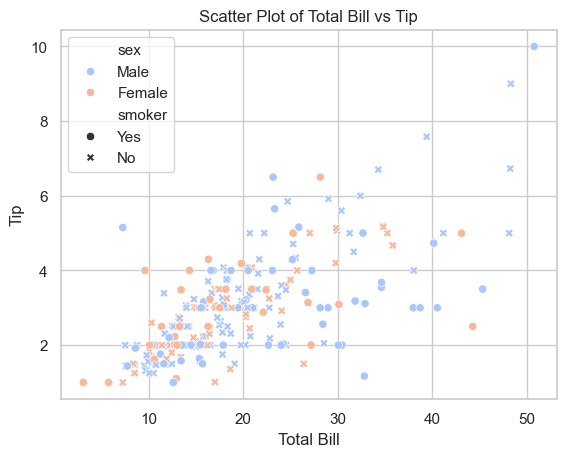

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex", style="smoker", palette="coolwarm")
plt.title("Scatter Plot of Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

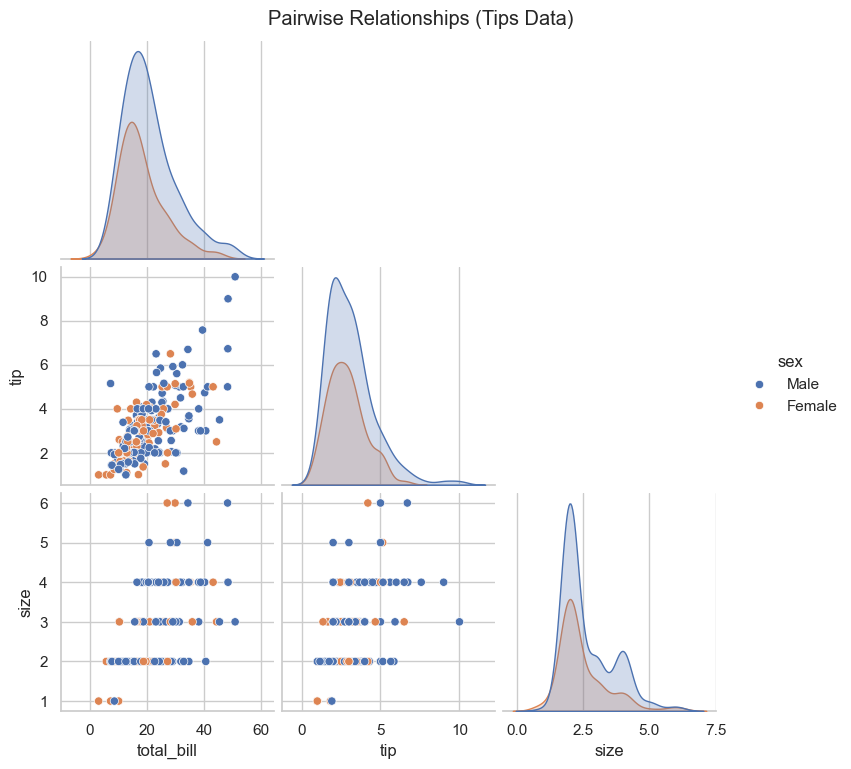

In [68]:
sns.pairplot(tips, hue="sex", diag_kind="kde", corner=True)
plt.suptitle("Pairwise Relationships (Tips Data)", y=1.02)
plt.show()

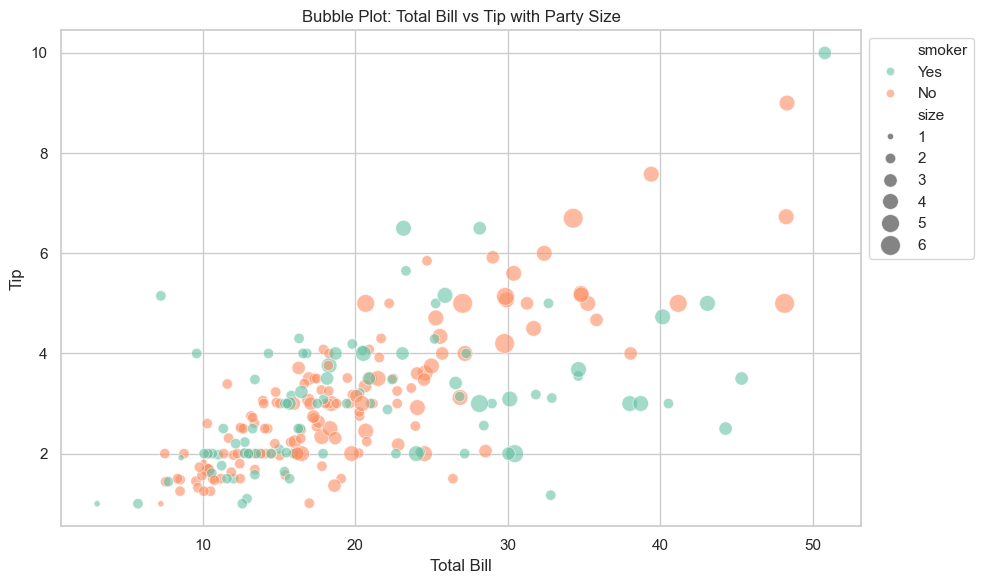

In [69]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    size="size",
    hue="smoker",
    alpha=0.6,
    palette="Set2",
    sizes=(20, 200)
)
plt.title("Bubble Plot: Total Bill vs Tip with Party Size")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

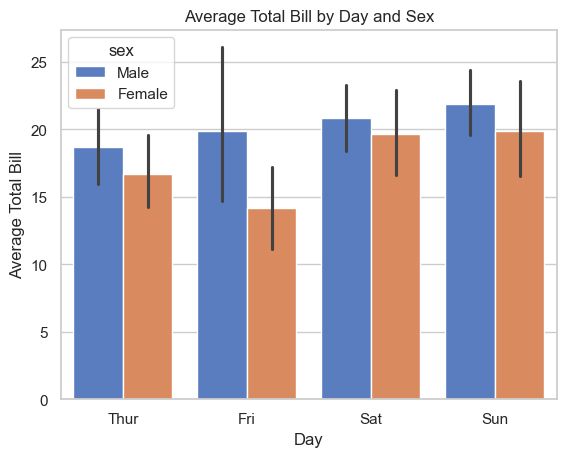

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=tips, x="day", y="total_bill", estimator="mean", hue="sex", palette="muted")
plt.title("Average Total Bill by Day and Sex")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.show()

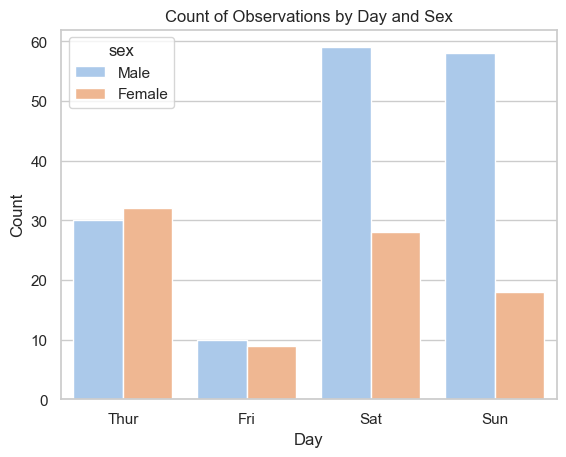

In [71]:
sns.countplot(data=tips, x="day", hue="sex", palette="pastel")
plt.title("Count of Observations by Day and Sex")
plt.xlabel("Day")
plt.ylabel("Count")
plt.show()

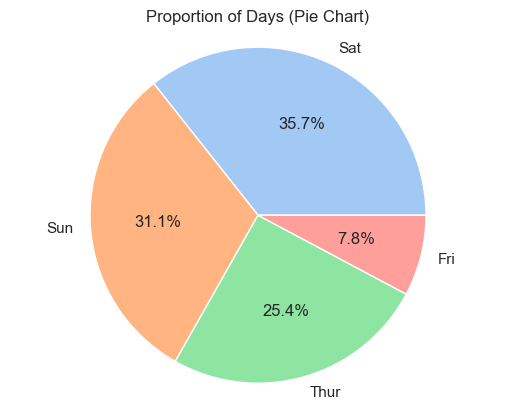

In [72]:
# Count of entries per day
counts = tips["day"].value_counts()

plt.pie(counts, labels=counts.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title("Proportion of Days (Pie Chart)")
plt.axis("equal")
plt.show()

C:\Users\ramir\AppData\Local\Temp\ipykernel_94872\1759597149.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = tips.pivot_table(index="day", columns="time", values="total_bill", aggfunc="mean")


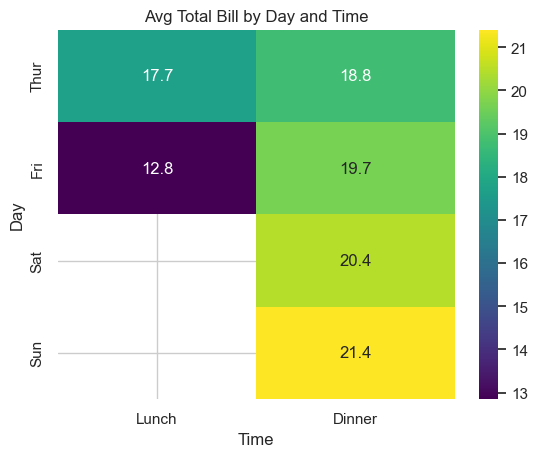

In [73]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Pivot table: average total_bill by day and time
pivot = tips.pivot_table(index="day", columns="time", values="total_bill", aggfunc="mean")

sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".1f")
plt.title("Avg Total Bill by Day and Time")
plt.xlabel("Time")
plt.ylabel("Day")
plt.show()

In [74]:
!pip install squarify

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\ramir\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


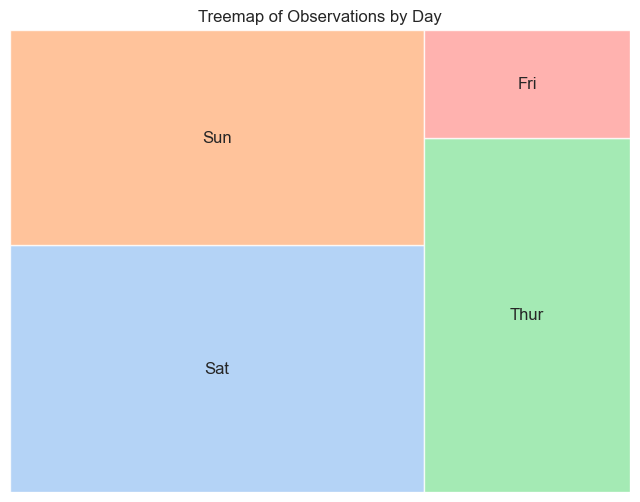

In [75]:
import squarify
import matplotlib.pyplot as plt

category_counts = tips["day"].value_counts()

plt.figure(figsize=(8,6))
squarify.plot(sizes=category_counts.values, 
              label=category_counts.index, 
              color=sns.color_palette("pastel"),
              alpha=.8)
plt.title("Treemap of Observations by Day")
plt.axis("off")
plt.show()


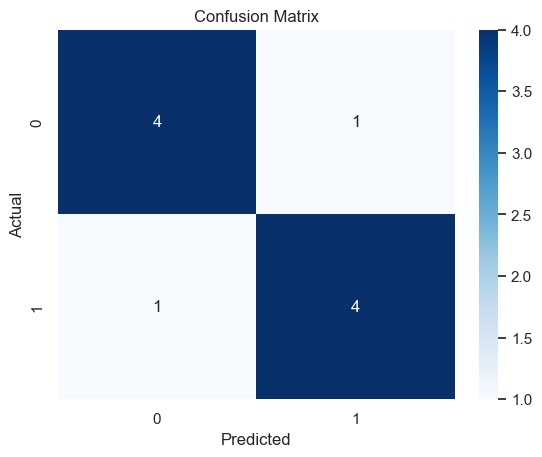

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Example ground truth and predictions
y_true = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]
y_pred = [1, 0, 1, 0, 0, 1, 1, 0, 1, 0]

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

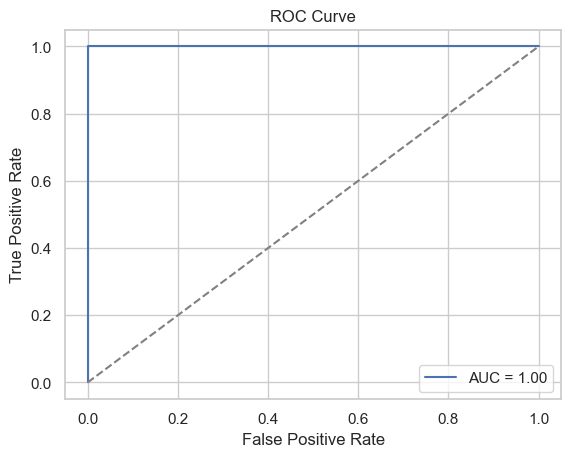

In [77]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Simulated probabilities and binary labels
y_probs = [0.91, 0.35, 0.88, 0.67, 0.12, 0.97, 0.33, 0.22, 0.85, 0.15]
fpr, tpr, _ = roc_curve(y_true, y_probs)
auc_score = roc_auc_score(y_true, y_probs)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

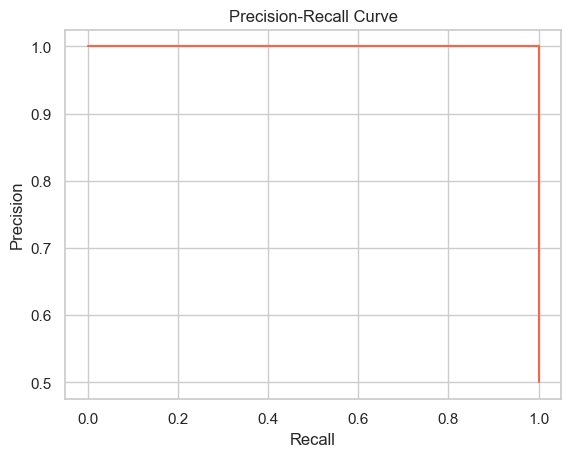

In [78]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_probs)

plt.plot(recall, precision, color="tomato")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

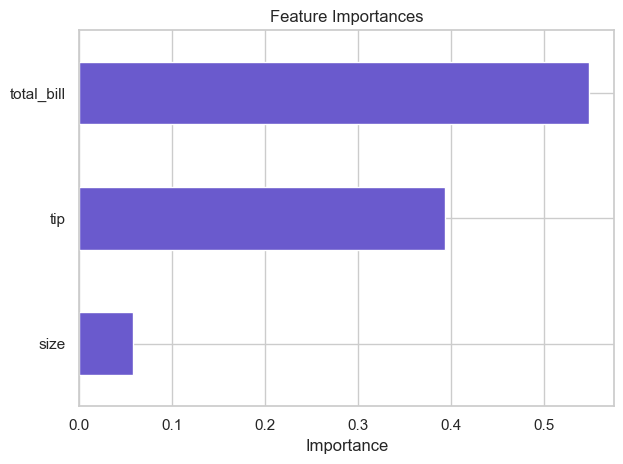

In [85]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample model and data
X = tips[["total_bill", "tip", "size"]]
y = tips["sex"].map({"Male": 1, "Female": 0})  # binary target
y = y.astype(float)
model = RandomForestClassifier(n_estimators=50, random_state=0)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", color="slateblue")
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [86]:
y

0      0.0
1      1.0
2      1.0
3      1.0
4      0.0
      ... 
239    1.0
240    0.0
241    1.0
242    1.0
243    0.0
Name: sex, Length: 244, dtype: float64

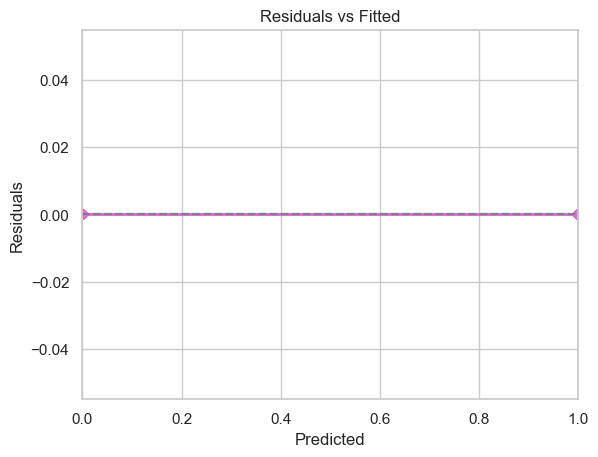

In [87]:
import numpy as np

# Simulate predictions
y_pred = model.predict(X)
residuals = y - y_pred

sns.residplot(x=y_pred, y=residuals, lowess=True, color="orchid")
plt.title("Residuals vs Fitted")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.axhline(0, linestyle="--", color="gray")
plt.show()